In [1]:
import sys
sys.path.append("../src")

import os
import cv2
import matplotlib.pyplot as plt
from video_loader import sample_frames

In [2]:
video_path = "../data/artificial_jewellery/video_20260405_105612_edit.mp4"  # change this
frames = sample_frames(video_path, sample_rate=30)
print("Sampled frames:", len(frames))

Sampled frames: 11


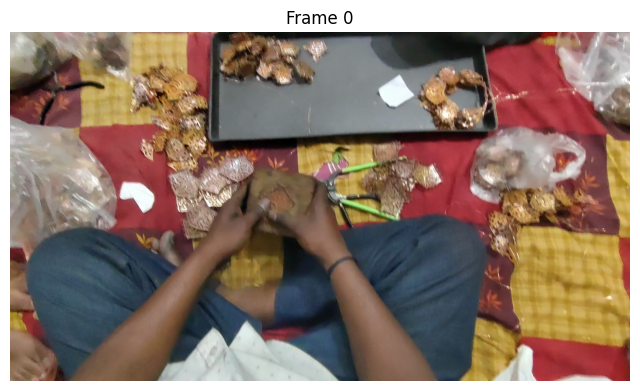

In [3]:
def show_frame(frame, title="Frame"):
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

frame_idx, frame = frames[0]
show_frame(frame, f"Frame {frame_idx}")

In [4]:
def blur_score(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

In [5]:
clean_frames = []

for idx, frame in frames:
    score = blur_score(frame)
    if score > 100:   # threshold can be tuned
        clean_frames.append((idx, frame, score))

print("Clean frames:", len(clean_frames))

Clean frames: 8


In [6]:
save_dir = "../outputs/sampled_frames"
os.makedirs(save_dir, exist_ok=True)

for idx, frame, score in clean_frames:
    out_path = os.path.join(save_dir, f"frame_{idx}.jpg")
    cv2.imwrite(out_path, frame)

print("Saved clean frames to:", save_dir)

Saved clean frames to: ../outputs/sampled_frames
